# Imports

In [1]:
import numpy as np
import sympy as sp
from numba import njit

Mis funciones definidas en `/code/src/`

In [2]:
import sys
import os

# Navigate up to the 'code' directory, then into 'src'
sys.path.append(os.path.abspath('../src'))

# Import the functions
from dynamics import generate_orbit, generate_escape_time_fractal, generate_fatou_basins, make_generate_orbit_jitted, make_generate_escape_time_fractal_jitted, make_generate_fatou_basins_jitted
from utils import DynamicsPlotter

# Ejemplo del libro (Möbius Transformation)

## Comprobación de que eligiendo $\epsilon$ negativo y pequeño, inicialmente diverge

In [3]:
# Transformation coefficients: (az + b) / (cz + d)
# These specific values often lead to interesting spiral behaviors
a, b = 3, -2
c, d = 2, -1

def R(z):
    return (a*z + b)/(c*z + d)

In [4]:
epsilon = -0.01
zeta = 1

z0 = zeta + epsilon

In [5]:
max_iter = 50
orbit = generate_orbit(z0, R, max_iter=max_iter)

Me ha parecido curioso que de repente explote y se vaya al $-1.5 \cdot 10^{11}$

<Axes: title={'center': 'Orbit of $R(z) = \\frac{3z - 2}{2z - 1}$ for $z_0 = 0.99 + 0.0i$'}>

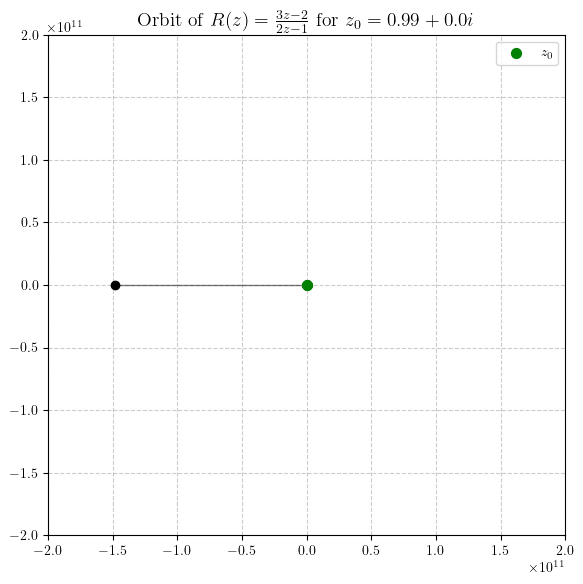

In [6]:
center = complex(1, 0)
max_distance_to_center = 2e11

xmin = center.real - max_distance_to_center
xmax = center.real + max_distance_to_center
ymin = center.imag - max_distance_to_center
ymax = center.imag + max_distance_to_center

title = rf"Orbit of $R(z) = \frac{{3z - 2}}{{2z - 1}}$ for $z_0 = {round(z0.real, 2)} + {round(z0.imag, 2)}i$"

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_orbit(orbit, title=title)
plotter.add_points(ax, [z0], label="$z_0$", marker='o', color='green', s=50)

Para que se vea bien los puntos por los que pasa he decidido mostrarlos como una ristra de números (en vez de en una gráfica)}

In [7]:
index = 1
for z in orbit:
    print(index, ':\t', z)
    index += 1

1 :	 (0.99+0j)
2 :	 (0.9897959183673467+0j)
3 :	 (0.9895833333333333+0j)
4 :	 (0.9893617021276597+0j)
5 :	 (0.9891304347826089+0j)
6 :	 (0.9888888888888892+0j)
7 :	 (0.9886363636363642+0j)
8 :	 (0.9883720930232563+0j)
9 :	 (0.9880952380952387+0j)
10 :	 (0.9878048780487811+0j)
11 :	 (0.9875000000000008+0j)
12 :	 (0.9871794871794882+0j)
13 :	 (0.9868421052631592+0j)
14 :	 (0.9864864864864877+0j)
15 :	 (0.9861111111111125+0j)
16 :	 (0.9857142857142871+0j)
17 :	 (0.9852941176470602+0j)
18 :	 (0.9848484848484863+0j)
19 :	 (0.9843750000000017+0j)
20 :	 (0.9838709677419372+0j)
21 :	 (0.983333333333335+0j)
22 :	 (0.9827586206896567+0j)
23 :	 (0.9821428571428589+0j)
24 :	 (0.9814814814814833+0j)
25 :	 (0.9807692307692328+0j)
26 :	 (0.9800000000000025+0j)
27 :	 (0.9791666666666693+0j)
28 :	 (0.9782608695652203+0j)
29 :	 (0.9772727272727304+0j)
30 :	 (0.9761904761904799+0j)
31 :	 (0.9750000000000043+0j)
32 :	 (0.9736842105263207+0j)
33 :	 (0.9722222222222276+0j)
34 :	 (0.9705882352941237+0j)
35 :

Se puede ver con más zoom que las primeras iteraciones diverge

<Axes: title={'center': 'Orbit of $R(z) = \\frac{3z - 2}{2z - 1}$ for $z_0 = 0.99 + 0.0i$'}>

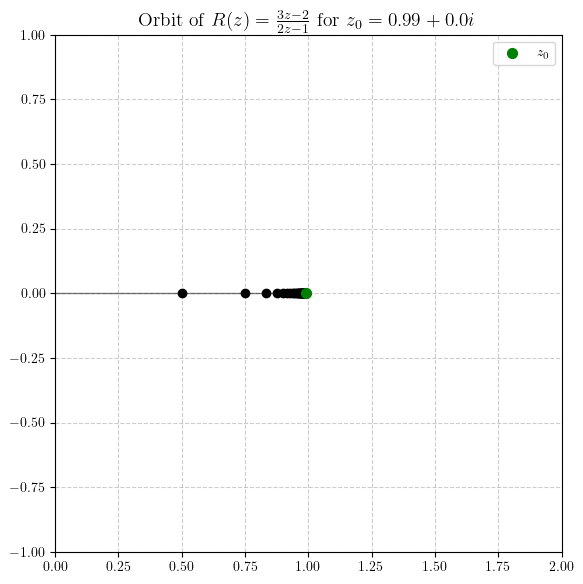

In [13]:
center = complex(1, 0)
max_distance_to_center = 1

xmin = center.real - max_distance_to_center
xmax = center.real + max_distance_to_center
ymin = center.imag - max_distance_to_center
ymax = center.imag + max_distance_to_center

title = rf"Orbit of $R(z) = \frac{{3z - 2}}{{2z - 1}}$ for $z_0 = {round(z0.real, 2)} + {round(z0.imag, 2)}i$"

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_orbit(orbit, title=title)
plotter.add_points(ax, [z0], label="$z_0$", marker='o', color='green', s=50)

## Comprobación de que eventualmente converge

Si cogemos suficientes iteraciones (de hecho después de irse al $-10^{12}$ vuelve al $1.5$), se ve como sigue convergiendo al $1$ cómo hemos probado a mano

In [14]:
epsilon = -0.01
zeta = 1

z0 = zeta + epsilon

In [ ]:
max_iter = 100
orbit = generate_orbit(z0, R, max_iter=max_iter)

Aquí se pueden ver las primeras iteraciones que van hacia la izquierda alejándose del $1$, pero después vuelve por la derecha

<Axes: title={'center': 'Orbit of $R(z) = \\frac{3z - 2}{2z - 1}$ for $z_0 = 0.99 + 0.0i$'}>

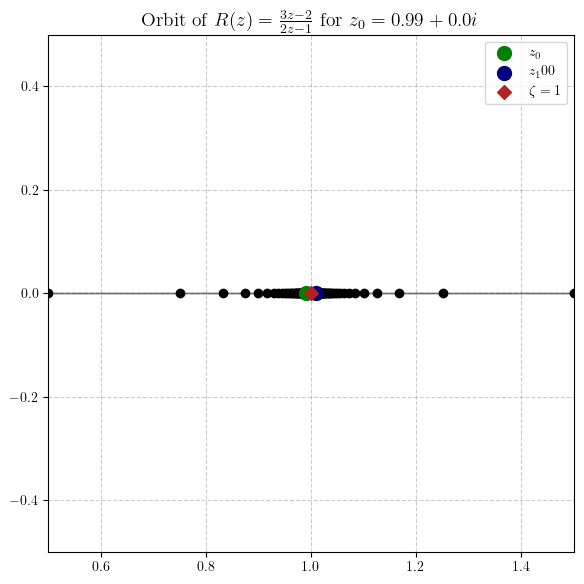

In [ ]:
center = complex(1, 0)
max_distance_to_center = 0.5

xmin = center.real - max_distance_to_center
xmax = center.real + max_distance_to_center
ymin = center.imag - max_distance_to_center
ymax = center.imag + max_distance_to_center

title = rf"Orbit of $R(z) = \frac{{3z - 2}}{{2z - 1}}$ for $z_0 = {round(z0.real, 2)} + {round(z0.imag, 2)}i$"

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_orbit(orbit, title=title)
plotter.add_points(ax, [z0], label="$z_0$", marker='o', color='green', s=100)
plotter.add_points(ax, [orbit[-1]], label=rf"$z_{{max_iter}}$", marker='o', color='navy', s=100)
plotter.add_points(ax, [1], label="$\zeta = 1$", marker='D', color='firebrick', s=50)

Para que se vea bien los puntos por los que pasa he decidido mostrarlos como una ristra de números (en vez de en una gráfica)

In [39]:
i = 1
for z in orbit:
    print(i, ':\t', z)
    i += 1

1 :	 (0.99+0j)
2 :	 (0.9897959183673467+0j)
3 :	 (0.9895833333333333+0j)
4 :	 (0.9893617021276597+0j)
5 :	 (0.9891304347826089+0j)
6 :	 (0.9888888888888892+0j)
7 :	 (0.9886363636363642+0j)
8 :	 (0.9883720930232563+0j)
9 :	 (0.9880952380952387+0j)
10 :	 (0.9878048780487811+0j)
11 :	 (0.9875000000000008+0j)
12 :	 (0.9871794871794882+0j)
13 :	 (0.9868421052631592+0j)
14 :	 (0.9864864864864877+0j)
15 :	 (0.9861111111111125+0j)
16 :	 (0.9857142857142871+0j)
17 :	 (0.9852941176470602+0j)
18 :	 (0.9848484848484863+0j)
19 :	 (0.9843750000000017+0j)
20 :	 (0.9838709677419372+0j)
21 :	 (0.983333333333335+0j)
22 :	 (0.9827586206896567+0j)
23 :	 (0.9821428571428589+0j)
24 :	 (0.9814814814814833+0j)
25 :	 (0.9807692307692328+0j)
26 :	 (0.9800000000000025+0j)
27 :	 (0.9791666666666693+0j)
28 :	 (0.9782608695652203+0j)
29 :	 (0.9772727272727304+0j)
30 :	 (0.9761904761904799+0j)
31 :	 (0.9750000000000043+0j)
32 :	 (0.9736842105263207+0j)
33 :	 (0.9722222222222276+0j)
34 :	 (0.9705882352941237+0j)
35 :

## Generación de puntos iniciales cerca del $1$ aleatorios para ver diferentes comportamientos

In [40]:
radius = 0.5
r_real = np.random.uniform(-radius, radius)
r_imag = np.random.uniform(-radius, radius)
r = complex(r_real, r_imag)
zeta = 1

z0 = zeta + r

In [41]:
max_iter = 100
orbit = generate_orbit(z0, R, max_iter=max_iter)

<Axes: title={'center': 'Orbit of $R(z) = \\frac{3z - 2}{2z - 1}$ for $z_0 = 0.54 + -0.4i$'}>

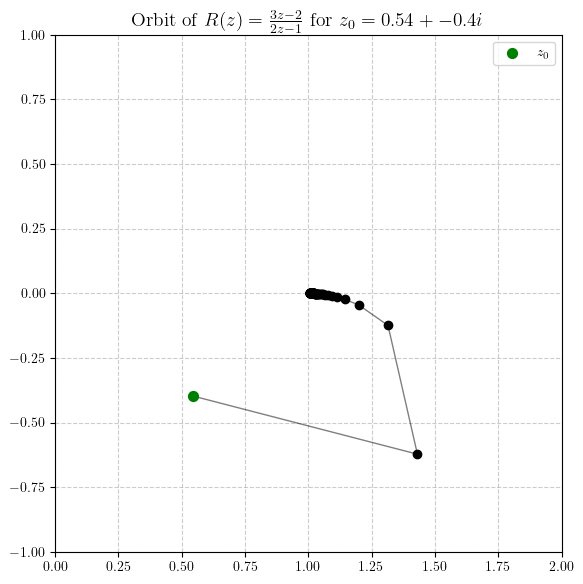

In [42]:
center = complex(1, 0)
max_distance_to_center = 1

xmin = center.real - max_distance_to_center
xmax = center.real + max_distance_to_center
ymin = center.imag - max_distance_to_center
ymax = center.imag + max_distance_to_center

title = rf"Orbit of $R(z) = \frac{{3z - 2}}{{2z - 1}}$ for $z_0 = {round(z0.real, 2)} + {round(z0.imag, 2)}i$"

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_orbit(orbit, title=title)
plotter.add_points(ax, [z0], label="$z_0$", marker='o', color='green', s=50)

# Ejercicio 3

In [43]:
def R(z):
    return 2*z/(z+1)

Hemos analizado en papel que todas las iteraciones hacia atrás parten del $0$ ($(R^{-1})^n \to 0$) y hacia adelante llegan al $1$ ($R^n \to 1$). Así que voy a tomar puntos aleatorios cerca del $0$ (distancia de $0.1$ o menos en parte real e imaginaria, y veo cómo llegan al $1$). Para ver diferentes puntos iniciales ejecutar varias veces las celdas.

In [44]:
radius = 0.1
r_real = np.random.uniform(-radius, radius)
r_imag = np.random.uniform(-radius, radius)
r = complex(r_real, r_imag)
zeta = 0

z0 = zeta + r

In [45]:
max_iter = 100
orbit = generate_orbit(z0, R, max_iter=max_iter)

<Axes: title={'center': 'Orbit of $R(z) = \\frac{2z}{z + 1}$ for $z_0 = -0.07 + 0.08i$'}>

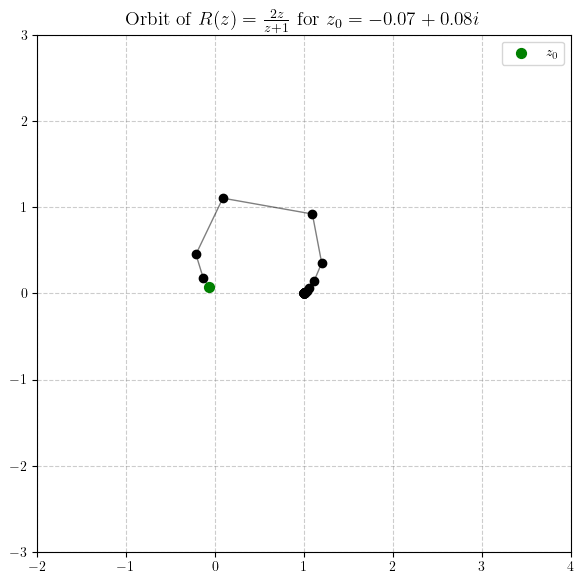

In [46]:
center = complex(1, 0)
max_distance_to_center = 3

xmin = center.real - max_distance_to_center
xmax = center.real + max_distance_to_center
ymin = center.imag - max_distance_to_center
ymax = center.imag + max_distance_to_center

title = rf"Orbit of $R(z) = \frac{{2z}}{{z + 1}}$ for $z_0 = {round(z0.real, 2)} + {round(z0.imag, 2)}i$"

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_orbit(orbit, title=title)
plotter.add_points(ax, [z0], label="$z_0$", marker='o', color='green', s=50)

Por comodidad para ejecutar múltiples veces lo he juntado en una celda

<Axes: title={'center': 'Orbit of $R(z) = \\frac{2z}{z + 1}$ for $z_0 = 0.01 + -0.04i$'}>

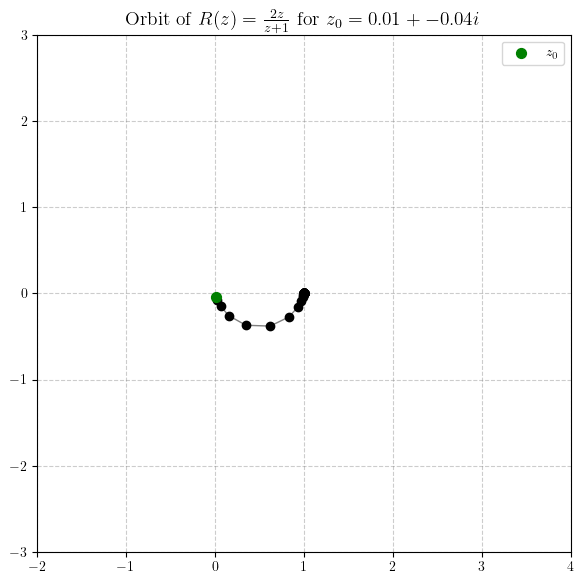

In [50]:
radius = 0.1
r_real = np.random.uniform(-radius, radius)
r_imag = np.random.uniform(-radius, radius)
r = complex(r_real, r_imag)
zeta = 0

z0 = zeta + r

max_iter = 100
orbit = generate_orbit(z0, R, max_iter=max_iter)

center = complex(1, 0)
max_distance_to_center = 3

xmin = center.real - max_distance_to_center
xmax = center.real + max_distance_to_center
ymin = center.imag - max_distance_to_center
ymax = center.imag + max_distance_to_center

title = rf"Orbit of $R(z) = \frac{{2z}}{{z + 1}}$ for $z_0 = {round(z0.real, 2)} + {round(z0.imag, 2)}i$"

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_orbit(orbit, title=title)
plotter.add_points(ax, [z0], label="$z_0$", marker='o', color='green', s=50)

# Ejercicio 4

In [51]:
def R(z):
    return z/(2*z+1)

Hemos analizado en papel que tiene un punto fijo indiferente y es $0$. Además, todas las secuencias de iteraciones de R eventualmente convergen a $0$.

In [52]:
radius = 2
r_real = np.random.uniform(-radius, radius)
r_imag = np.random.uniform(-radius, radius)
r = complex(r_real, r_imag)
zeta = 0

z0 = zeta + r

In [53]:
max_iter = 100
orbit = generate_orbit(z0, R, max_iter=max_iter)

<Axes: title={'center': 'Orbit of $R(z) = \\frac{z}{2z + 1}$ for $z_0 = -1.72 + -0.5i$'}>

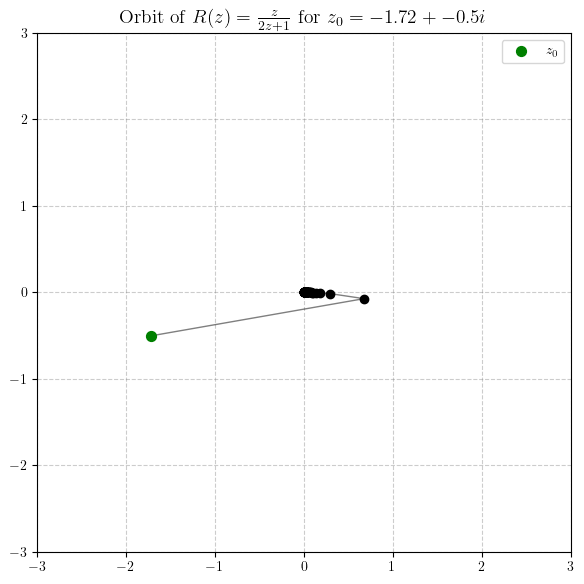

In [54]:
center = complex(0, 0)
max_distance_to_center = 3

xmin = center.real - max_distance_to_center
xmax = center.real + max_distance_to_center
ymin = center.imag - max_distance_to_center
ymax = center.imag + max_distance_to_center

title = rf"Orbit of $R(z) = \frac{{z}}{{2z + 1}}$ for $z_0 = {round(z0.real, 2)} + {round(z0.imag, 2)}i$"

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_orbit(orbit, title=title)
plotter.add_points(ax, [z0], label="$z_0$", marker='o', color='green', s=50)

Por comodidad para ejecutar múltiples veces lo he juntado en una celda

<Axes: title={'center': 'Orbit of $R(z) = \\frac{z}{2z + 1}$ for $z_0 = -0.38 + 1.86i$'}>

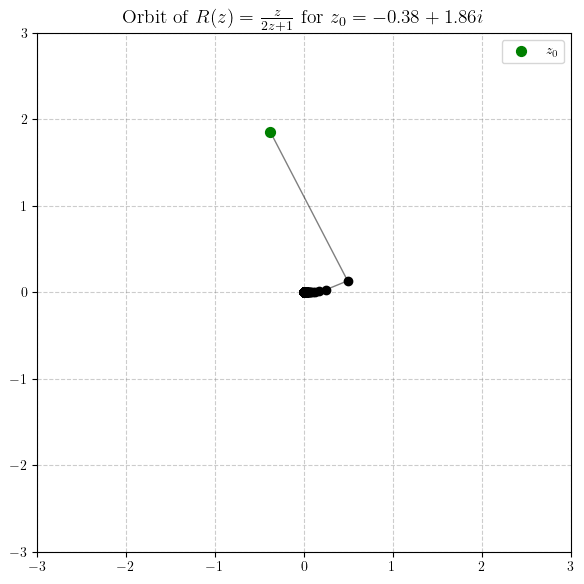

In [55]:
radius = 2
r_real = np.random.uniform(-radius, radius)
r_imag = np.random.uniform(-radius, radius)
r = complex(r_real, r_imag)
zeta = 0

z0 = zeta + r

max_iter = 1000
orbit = generate_orbit(z0, R, max_iter=max_iter)

center = complex(0, 0)
max_distance_to_center = 3

xmin = center.real - max_distance_to_center
xmax = center.real + max_distance_to_center
ymin = center.imag - max_distance_to_center
ymax = center.imag + max_distance_to_center

title = rf"Orbit of $R(z) = \frac{{z}}{{2z + 1}}$ for $z_0 = {round(z0.real, 2)} + {round(z0.imag, 2)}i$"

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_orbit(orbit, title=title)
plotter.add_points(ax, [z0], label="$z_0$", marker='o', color='green', s=50)

Hago más zoom para ver si se nota que $0$ es indiferente en convergencia más lenta o no se nota nada

<Axes: title={'center': 'Orbit of $R(z) = \\frac{z}{2z + 1}$ for $z_0 = -0.38 + 1.86i$'}>

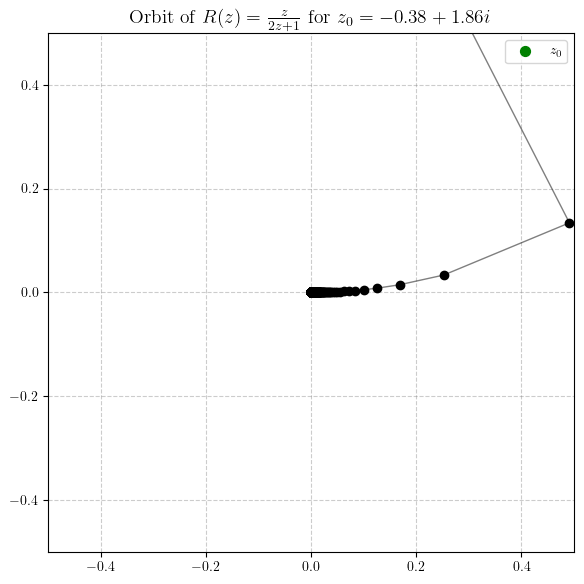

In [56]:
center = complex(0, 0)
max_distance_to_center = 0.5

xmin = center.real - max_distance_to_center
xmax = center.real + max_distance_to_center
ymin = center.imag - max_distance_to_center
ymax = center.imag + max_distance_to_center

title = rf"Orbit of $R(z) = \frac{{z}}{{2z + 1}}$ for $z_0 = {round(z0.real, 2)} + {round(z0.imag, 2)}i$"

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_orbit(orbit, title=title)
plotter.add_points(ax, [z0], label="$z_0$", marker='o', color='green', s=50)

<Axes: title={'center': 'Orbit of $R(z) = \\frac{z}{2z + 1}$ for $z_0 = -0.38 + 1.86i$'}>

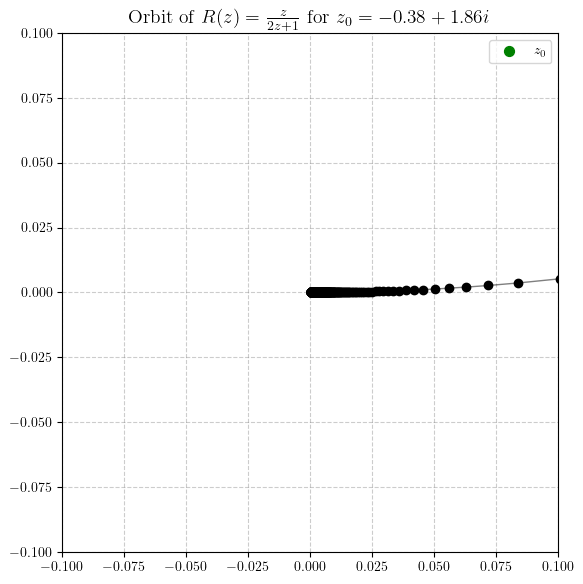

In [57]:
center = complex(0, 0)
max_distance_to_center = 1e-1

xmin = center.real - max_distance_to_center
xmax = center.real + max_distance_to_center
ymin = center.imag - max_distance_to_center
ymax = center.imag + max_distance_to_center

title = rf"Orbit of $R(z) = \frac{{z}}{{2z + 1}}$ for $z_0 = {round(z0.real, 2)} + {round(z0.imag, 2)}i$"

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_orbit(orbit, title=title)
plotter.add_points(ax, [z0], label="$z_0$", marker='o', color='green', s=50)

<Axes: title={'center': 'Orbit of $R(z) = \\frac{z}{2z + 1}$ for $z_0 = -0.38 + 1.86i$'}>

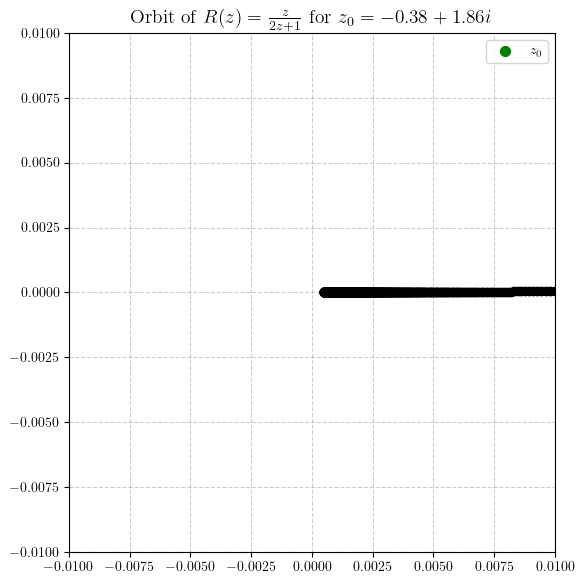

In [60]:
center = complex(0, 0)
max_distance_to_center = 1e-2

xmin = center.real - max_distance_to_center
xmax = center.real + max_distance_to_center
ymin = center.imag - max_distance_to_center
ymax = center.imag + max_distance_to_center

title = rf"Orbit of $R(z) = \frac{{z}}{{2z + 1}}$ for $z_0 = {round(z0.real, 2)} + {round(z0.imag, 2)}i$"

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_orbit(orbit, title=title)
plotter.add_points(ax, [z0], label="$z_0$", marker='o', color='green', s=50)

# Ejercicio 5

In [61]:
a = complex(1, 1)
b = complex(1, -1)

def R(z):
    return (a*z + b)/(b*z + a)

Hemos analizado en papel que tiene dos puntos fijos indiferentes, $1$ y $-1$. Además, todas las secuencias de iteraciones de R son cíclicas de grado 4 (menos las que empiezan en los puntos fijos, que son siempre el punto fijo).

In [66]:
radius = 2
r_real = np.random.uniform(-radius, radius)
r_imag = np.random.uniform(-radius, radius)
r = complex(r_real, r_imag)
zeta1 = 1
zeta2 = -1

z0 = (zeta1+zeta2)/2 + r

In [67]:
max_iter = 4
orbit = generate_orbit(z0, R, max_iter=max_iter)

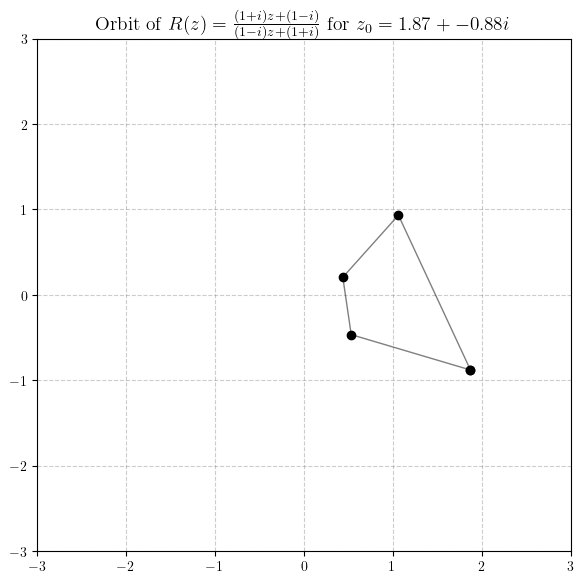

In [68]:
center = complex(0, 0)
max_distance_to_center = 3

xmin = center.real - max_distance_to_center
xmax = center.real + max_distance_to_center
ymin = center.imag - max_distance_to_center
ymax = center.imag + max_distance_to_center

title = rf"Orbit of $R(z) = \frac{{(1+i)z + (1-i)}}{{(1-i)z + (1+i)}}$ for $z_0 = {round(z0.real, 2)} + {round(z0.imag, 2)}i$"

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_orbit(orbit, title=title)

Además, sabemos que todos los puntos de la secuencia caen en un círculo o recta, el siguiente código sirve para visualizarlo

In [69]:
import matplotlib.pyplot as plt

def add_circle_to_plotter(z0, fig, ax):
    # Calculate and Plot the Apollonian Circle
    C = abs((z0 - 1) / (z0 + 1))

    # Check if the locus is a straight line (imaginary axis)
    if not np.isclose(C, 1.0):
        # Calculate mathematical center
        x_c = (1 + C**2) / (1 - C**2)
        c_circle = complex(x_c, 0)
        radius_circle = abs(z0 - c_circle)

        # Plot the circle center
        ax.scatter(c_circle.real, c_circle.imag, color='lightgray', marker='x', s=50, label='Circle Center', zorder=6)

        # Draw the circle locus
        circle = plt.Circle((c_circle.real, c_circle.imag), radius_circle, 
                            color='lightgray', fill=False, linestyle='--', linewidth=1.5, alpha=0.5, label='Apollonian Orbit Locus')
        fig.gca().add_patch(circle)
    else:
        ax.axvline(0, color='lightgray', linestyle='--', label='Orbit Locus (Imaginary Axis)')

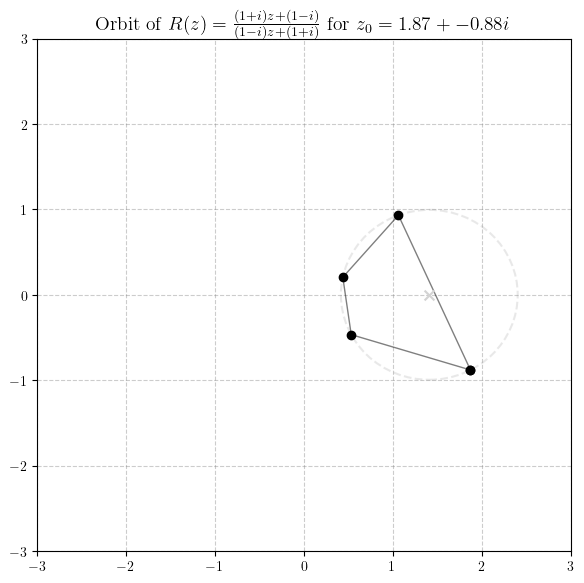

In [71]:
xmin = center.real - max_distance_to_center
xmax = center.real + max_distance_to_center
ymin = center.imag - max_distance_to_center
ymax = center.imag + max_distance_to_center

title = rf"Orbit of $R(z) = \frac{{(1+i)z + (1-i)}}{{(1-i)z + (1+i)}}$ for $z_0 = {round(z0.real, 2)} + {round(z0.imag, 2)}i$"

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_orbit(orbit, title=title)

add_circle_to_plotter(z0, fig, ax)

Por comodidad para ejecutar múltiples veces lo he juntado en una celda

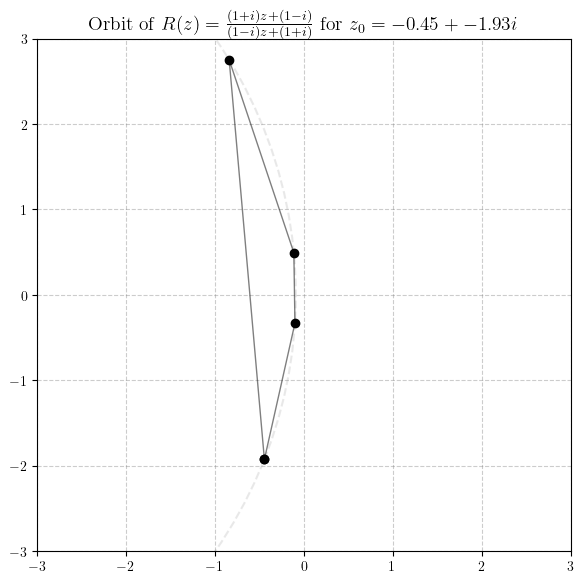

In [73]:
radius = 2
r_real = np.random.uniform(-radius, radius)
r_imag = np.random.uniform(-radius, radius)
r = complex(r_real, r_imag)
zeta1 = 1
zeta2 = -1

z0 = (zeta1+zeta2)/2 + r

max_iter = 4
orbit = generate_orbit(z0, R, max_iter=max_iter)

center = complex(0, 0)
max_distance_to_center = 3

xmin = center.real - max_distance_to_center
xmax = center.real + max_distance_to_center
ymin = center.imag - max_distance_to_center
ymax = center.imag + max_distance_to_center

title = rf"Orbit of $R(z) = \frac{{(1+i)z + (1-i)}}{{(1-i)z + (1+i)}}$ for $z_0 = {round(z0.real, 2)} + {round(z0.imag, 2)}i$"

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_orbit(orbit, title=title)

add_circle_to_plotter(z0, fig, ax)

Pruebo con puntos en el eje imaginario porque me ha salido una vez por azar y se ve que el ciclo puede ser en una recta

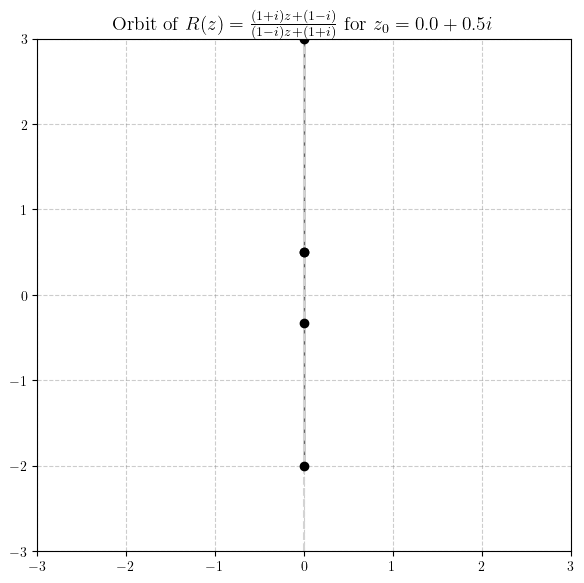

In [74]:
z0 = complex(0, 0.5)

max_iter = 4
orbit = generate_orbit(z0, R, max_iter=max_iter)

center = complex(0, 0)
max_distance_to_center = 3

xmin = center.real - max_distance_to_center
xmax = center.real + max_distance_to_center
ymin = center.imag - max_distance_to_center
ymax = center.imag + max_distance_to_center

title = rf"Orbit of $R(z) = \frac{{(1+i)z + (1-i)}}{{(1-i)z + (1+i)}}$ for $z_0 = {round(z0.real, 2)} + {round(z0.imag, 2)}i$"

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_orbit(orbit, title=title)

add_circle_to_plotter(z0, fig, ax)

# Ejemplo propio con "ciclos infinitos"

Voy a coger la versión más sencilla: $R(z) = kz$, con un $k$ con módulo uno pero que no sea raíz de la unidad, es decir, que $k=\exp(\frac{i2\pi}{\omega})$ con $\omega$ irracional. En particular, tomo $\omega = \pi$.

In [76]:
theta = 2 # 2*np.pi/np.pi, es decir, la vuelta completa partida en pi trozos
k = 1*np.exp(theta*1j)

def R(z):
    return k*z

Hemos analizado en papel que tiene dos puntos fijos indiferentes. Además, todas las secuencias de iteraciones de R forman conjuntos densos en una circunferencia o línea.

In [86]:
radius = 2
r_real = np.random.uniform(-radius, radius)
r_imag = np.random.uniform(-radius, radius)
z0 = complex(r_real, r_imag)

In [87]:
max_iter = 100
orbit = generate_orbit(z0, R, max_iter=max_iter)

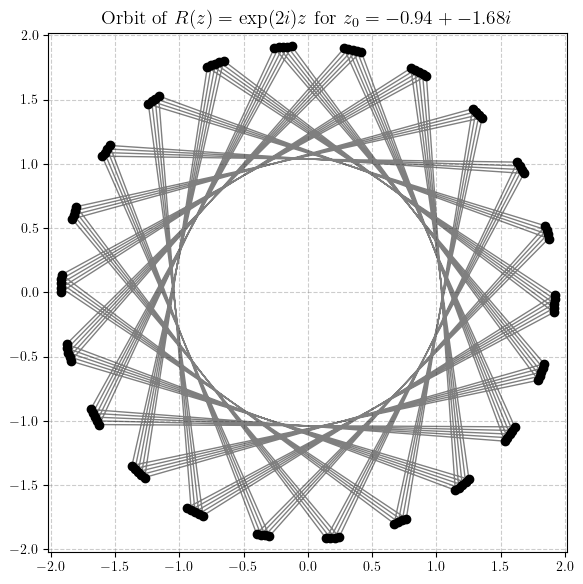

In [88]:
center = complex(0, 0)
max_distance_to_center = abs(z0) + 0.1

xmin = center.real - max_distance_to_center
xmax = center.real + max_distance_to_center
ymin = center.imag - max_distance_to_center
ymax = center.imag + max_distance_to_center

title = rf"Orbit of $R(z) = \exp(2i)z$ for $z_0 = {round(z0.real, 2)} + {round(z0.imag, 2)}i$"

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_orbit(orbit, title=title)

Por comodidad para ejecutar multiples veces lo he juntado en una celda

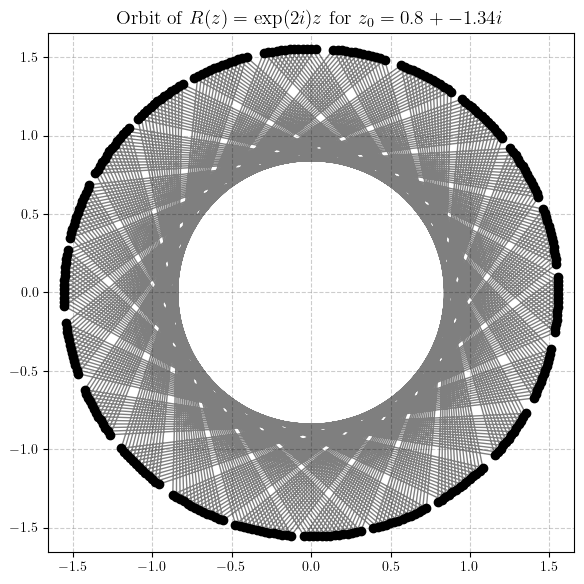

In [89]:
radius = 2
r_real = np.random.uniform(-radius, radius)
r_imag = np.random.uniform(-radius, radius)
z0 = complex(r_real, r_imag)

max_iter = 300
orbit = generate_orbit(z0, R, max_iter=max_iter)

center = complex(0, 0)
max_distance_to_center = abs(z0) + 0.1

xmin = center.real - max_distance_to_center
xmax = center.real + max_distance_to_center
ymin = center.imag - max_distance_to_center
ymax = center.imag + max_distance_to_center

title = rf"Orbit of $R(z) = \exp(2i)z$ for $z_0 = {round(z0.real, 2)} + {round(z0.imag, 2)}i$"

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_orbit(orbit, title=title)